In [2]:
from astropy.timeseries import TimeSeries
from astropy.time import Time
import numpy as np

t = Time(['2026-01-01', '2026-01-02', '2026-01-03'])
flux = [1.0, 0.9, 1.1]

ts = TimeSeries(time=t)
ts['flux'] = flux

ts

time,flux
Time,float64
2026-01-01 00:00:00.000,1.0
2026-01-02 00:00:00.000,0.9
2026-01-03 00:00:00.000,1.1


In [3]:
from astropy.table import Table
from astropy.time import TimeDelta
import astropy.units as u

tbl = Table.read("lightcurve.dat", format="ascii")

tbl.rename_columns(
    tbl.colnames,
    ['time', 'luminosity']
)

tbl['time'] = TimeDelta(tbl['time'], format='jd')

tbl['luminosity'].unit = u.erg / u.s

ts = TimeSeries(tbl)
ts

time,luminosity
,erg / s
TimeDelta,float64
0.023148148148148147,7.488922327747303e+36
0.034722222222222224,1.9957118204928043e+37
0.046296296296296294,3.7393685292874764e+37
0.05787037037037037,5.978773294630315e+37
0.06944444444444445,8.71283822039131e+37
0.08101851851851852,1.1940476577901358e+38
0.09259259259259259,1.5660602805017107e+38
0.10416666666666667,1.9872132505188176e+38


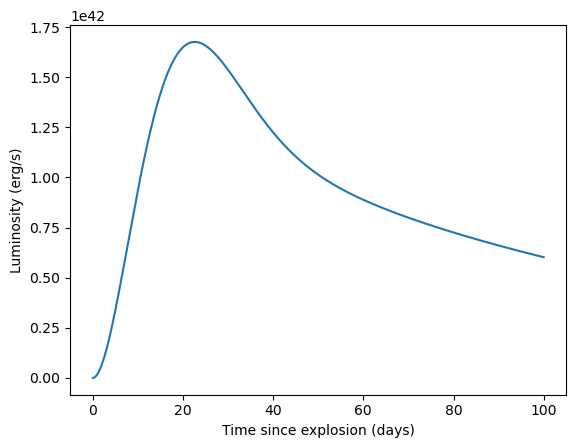

In [4]:
import matplotlib.pyplot as plt

plt.plot(ts.time.to_value(u.day), ts['luminosity'])
plt.xlabel("Time since explosion (days)")
plt.ylabel("Luminosity (erg/s)")
plt.show()

LOMB-SCARGLE: statistical method used to find periodic or quasi-periodic signals in unevenly sampled time-series data

- freq to power
- high power: timescale explains the data well, strong correlation with a sinusoid
- low power : no coherent signal at that timescale


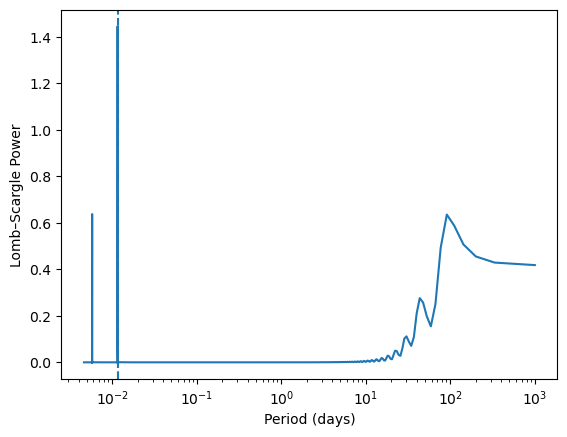

[4.17889847e-01 4.28749174e-01 4.55104698e-01 ... 7.01562957e-08
 3.66588526e-08 1.56828833e-08]


In [5]:
from astropy.timeseries import LombScargle

t = ts.time.to_value(u.day)
L = ts['luminosity']

ls = LombScargle(t, L)
freq, power = ls.autopower()

period = 1 / freq[np.argmax(power)]

phase = (t % period) / period

periods = 1 / freq

plt.figure()
plt.plot(periods, power)
plt.xscale('log')
plt.xlabel("Period (days)")
plt.ylabel("Lomb–Scargle Power")
plt.axvline(period, linestyle='--')
plt.show()

print(power)

ValueError: x and y must have same first dimension, but have shapes (8639,) and (107988,)

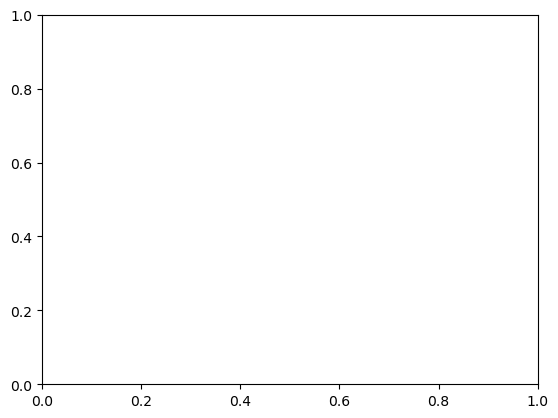

In [6]:
plt.figure()
plt.plot(phase, power)
plt.xscale('log')
plt.xlabel("Period (days)")
plt.ylabel("Lomb–Scargle Power")
plt.axvline(period, linestyle='--')
plt.show()

- Broad peaks : periodic variability
- Sharp, isolated peaks : suspicious for real periodicity
- Multiple peaks : multi-mode or stochastic (random) behavior